In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.integrate as integrate
from scipy import optimize
import plotly.graph_objects as go
import plotly.io as pio

In [2]:
eta_0 = 120 * np.pi  # Free space impedance
class layer:
    def __init__(self, f, eps, mu, theta, polarization,l=0, l_in_parts_of_wavelength=False, array_mode=False):
        self.eps = eps
        self.mu = mu
        self.l = l
        self.polarization = polarization
        self.theta = theta
        self.f = f
        self.array_mode = array_mode
        # if array_mode:
        #     self.f = f[:, None, None]
        #     self.theta = theta[None, None, :]
        self.w = 2 * np.pi * f # [:,None, None]
        mu0 = 4e-7 * np.pi
        eps0 = 8.854e-12
        eta_0 = np.sqrt(mu0/eps0)
        c = 1/np.sqrt(mu0*eps0)/1e9
        self.n = np.sqrt(mu * eps)
        if polarization == 'vert':
            self.z = eta_0/self.eps * np.sqrt(self.n**2 - (np.sin(theta)**2)) #[None, None, :]
        elif polarization == 'horiz':
            self.z = eta_0 * self.mu/np.sqrt(self.n**2 - (np.sin(theta)**2)) #[None, None, :]
        self.beta = self.w/c * np.sqrt(self.n**2 - (np.sin(theta)**2)) #[:, None, :]
        if l_in_parts_of_wavelength:
            self.l = l * 2*np.pi/self.beta
        self.phi = self.beta * self.l #[:, None, :]
    def abcd(self):
        abcd_res = np.array([[np.cos(self.phi), -1j*self.z*np.sin(self.phi)],
                        [-1j*(1/self.z)*np.sin(self.phi), np.cos(self.phi)]], dtype=complex)
        if self.array_mode:
            return abcd_res.transpose(2,3,4,0,1)
        return abcd_res

In [3]:
eta_0 = 120 * np.pi  # Free space impedance
class impedance_sheet:
    def __init__(self, f, L, theta, array_mode=False):
        self.f = f
        self.theta = theta
        self.array_mode = array_mode
        if array_mode:
            self.like_theta = np.ones_like(self.theta)
            self.like_f = np.ones_like(self.f)
        self.w = 2 * np.pi * f
        mu0 = 4e-7 * np.pi
        eps0 = 8.8541878188e-12
        eta_0 = np.sqrt(mu0/eps0)
        self.L = L
        self.z = 1j * self.w * L *1e9
    def abcd(self):
        abcd_res = np.array([[1*self.like_theta*self.like_f, 0*self.like_theta*self.like_f],
                        [-1/self.z*self.like_theta*self.like_f, 1*self.like_theta*self.like_f]], dtype=complex)
        if self.array_mode:
            return abcd_res.transpose(2,3,4,0,1)
        return abcd_res

In [4]:
def v_in(theta, phi, polarization):
    if polarization == 'vert':
        return np.cos(theta )*np.cos(phi)
    elif polarization == 'horiz':
        return np.sin(phi)
def z0(theta, polarization):
    if polarization == 'vert':
        return eta_0*np.cos(theta)
    elif polarization == 'horiz':
        return eta_0/np.cos(theta)

In [5]:
def e_on_direction(N, eps, mu, l, f=5, phi=0, theta=0): 
    E_res = 0
    for polarization in ['vert', 'horiz']:
        abcd_all = []
        for i in range(N):
            layer_i = layer(f, eps[i], mu[i], theta, polarization, l=l[i])
            abcd_all.append(layer_i.abcd())   
        v_in_i = v_in(theta, phi, polarization)
        z0_i = z0(theta, polarization)
        abcd_total = np.eye(2, dtype=complex)
        for abcd in abcd_all:
            abcd_total = np.matmul(abcd_total, abcd)
        A, B, C, D = abcd_total.flatten()
        I_0 = (-C*B/A+D)*2*v_in_i/(z0_i-B/A)
        shift_layer = layer(f, eps[0], mu[0], theta, polarization, l=l[0]/2)
        abcd_shift = np.linalg.inv(shift_layer.abcd())
        A_s, B_s, C_s, D_s = abcd_shift.flatten()
        E_res += np.abs(B_s*I_0)**2
    return np.sqrt(E_res)
def l_for_article_resonance_structure(N, eps, mu, f=5, theta = 0):
    l = np.zeros(N)
    for i in range(N):
        layer_i = layer(f, eps[i], mu[i], theta, 'vert', l=0.25, l_in_parts_of_wavelength=True)
        l[i] = layer_i.l
    l[0] *= 2

In [6]:
def v_in(theta, phi, polarization):
    if polarization == 'vert':
        return np.cos(theta )*np.cos(phi)
    elif polarization == 'horiz':
        return np.sin(phi)
    
def z0(theta, polarization):
    if polarization == 'vert':
        return eta_0*np.cos(theta)
    elif polarization == 'horiz':
        return eta_0/np.cos(theta)

def e_on_direction_array(N, eps, mu, l, f, phi, theta): 
    E_res = np.zeros((f.size, phi.size, theta.size), dtype=complex)
    f = f[:, None, None] 
    phi = phi[None, :, None]
    theta = theta[None, None, :]
    for polarization in ['vert', 'horiz']:
        abcd_all = []
        for i in range(N):
            layer_i = layer(f, eps[i], mu[i], theta, polarization, l=l[i], array_mode=True)
            abcd_all.append(layer_i.abcd())   #layer_i.abcd() должен быть 5-мерным массивом
        v_in_i = v_in(theta, phi, polarization)
        z0_i = z0(theta, polarization)
        abcd_total = np.eye(2, dtype=complex)
        for abcd in abcd_all:
            abcd_total = np.matmul(abcd_total, abcd)
        abcd_total = np.transpose(abcd_total, (3,4,0,1,2))
        A, B, C, D = abcd_total[0][0], abcd_total[0][1], abcd_total[1][0], abcd_total[1][1]
        I_0 = (-C*B/A+D)*2*v_in_i/(z0_i-B/A)
        shift_layer = layer(f, eps[0], mu[0], theta, polarization, l=l[0]/2, array_mode=True)
        abcd_shift = np.linalg.inv(shift_layer.abcd())
        abcd_shift = np.transpose(abcd_shift, (3,4,0,1,2))
        B_s = abcd_shift[0][1]
        E_res += np.abs(B_s*I_0)**2
    return np.sqrt(E_res)

def e_on_direction_array_with_sheets(N, eps, mu, l, mask, L, f, phi, theta): 
    E_res = np.zeros((f.size, phi.size, theta.size), dtype=complex)
    f = f[:, None, None] 
    phi = phi[None, :, None]
    theta = theta[None, None, :]
    for polarization in ['vert', 'horiz']:
        abcd_all = []
        for i in range(2*N+1):
            if mask[i]:
                layer_i = impedance_sheet(f, L[i], theta, array_mode=True)
            else:
                layer_i = layer(f, eps[i], mu[i], theta, polarization, l=l[i], array_mode=True)
            abcd_all.append(layer_i.abcd())   #layer_i.abcd() должен быть 5-мерным массивом
        v_in_i = v_in(theta, phi, polarization)
        z0_i = z0(theta, polarization)
        abcd_total = np.eye(2, dtype=complex)
        for abcd in abcd_all:
            abcd_total = np.matmul(abcd_total, abcd)
        abcd_total = np.transpose(abcd_total, (3,4,0,1,2))
        A, B, C, D = abcd_total[0][0], abcd_total[0][1], abcd_total[1][0], abcd_total[1][1]
        I_0 = (-C*B/A+D)*2*v_in_i/(z0_i-B/A)
        shift_layer = layer(f, eps[0], mu[0], theta, polarization, l=0.01500, array_mode=True)
        abcd_shift = np.linalg.inv(shift_layer.abcd())
        abcd_shift = np.transpose(abcd_shift, (3,4,0,1,2))
        B_s = abcd_shift[0][1]
        E_res += np.abs(B_s*I_0)**2
    return np.sqrt(E_res)

In [7]:
N = 2
eps = np.ones(2*N + 1)
mu = np.ones(2*N +1)
L = np.array([7.99446555e-9]*(2*N+1))
l = np.array([0.00614498]*(2*N+1))
l[0] = 0.02557249
l[2*N] = 0
alph = ([False, True]*N)
alph.append(False)
mask = np.array(alph)
print(e_on_direction_array_with_sheets(N, eps, mu, l, mask, L, np.array([5, 5.1]), np.array([0, 0.1]), np.array([0, 0.1])))

[[[7.99509234+0.j 7.8063842 +0.j]
  [7.99509234+0.j 7.80681877+0.j]]

 [[5.52177703+0.j 6.03818176+0.j]
  [5.52177703+0.j 6.04032138+0.j]]]


In [8]:
mu0 = 4e-7 * np.pi
eps0 = 8.8541878188e-12
eta_0 = np.sqrt(mu0/eps0)
c = 1/np.sqrt(mu0*eps0)/1e9
f_0 = 5
w_0 = 2 * np.pi * f_0
k = w_0/c
beta = lambda a: np.atan((a-np.sqrt(a**2+4))/2)+np.pi #a - alpha, b - beta
psi = lambda a: np.arctan(np.tan(beta(a))/(a*np.tan(beta(a))+1)) #здесь a и b для предыдущего слоя
beta1 = lambda a, a1: beta(a1) - psi(a) - np.pi
print(beta(1.5)/k)
print(eta_0/1.5/w_0*1e-9)

0.025554800248702155
7.99446554613413e-09


In [9]:
def e_on_direction_array_only_with_similar_sheets(N, alpha, f_0, f, phi, theta):
    w_0 = 2 * np.pi * f_0
    w = 2 * np.pi * f
    k = w_0/c
    beta = lambda a: np.atan((a-np.sqrt(a**2+4))/2)+np.pi #a - alpha, b - beta
    psi = lambda a: np.arctan(np.tan(beta(a))/(a*np.tan(beta(a))+1)) #здесь a и b для предыдущего слоя
    beta1 = lambda a, a1: beta(a1) - psi(a) - np.pi
    l = beta(alpha)/k
    l1 = beta1(alpha, alpha)/k
    L = eta_0/alpha/w_0*1e-9
    eps = np.ones(2*N + 1)
    mu = np.ones(2*N +1)
    L_arr = np.array([L]*(2*N+1))
    l_arr = np.array([l1]*(2*N+1))
    l_arr[0] = l
    l_arr[2*N] = 0
    a = ([False, True]*N)
    a.append(False)
    mask = np.array(a)
    return e_on_direction_array_with_sheets(N, eps, mu, l_arr, mask, L_arr, f, phi, theta)
    

In [10]:
print(e_on_direction_array_only_with_similar_sheets(2, 1.5, 5, np.array([5, 5.1]), np.array([0, 0.1]), np.array([0, 0.1])))

[[[8.00011301+0.j 7.76505029+0.j]
  [8.00011301+0.j 7.76533858+0.j]]

 [[5.60979943+0.j 6.12996783+0.j]
  [5.60979943+0.j 6.13214965+0.j]]]


15.998703591756
16.000616541538736


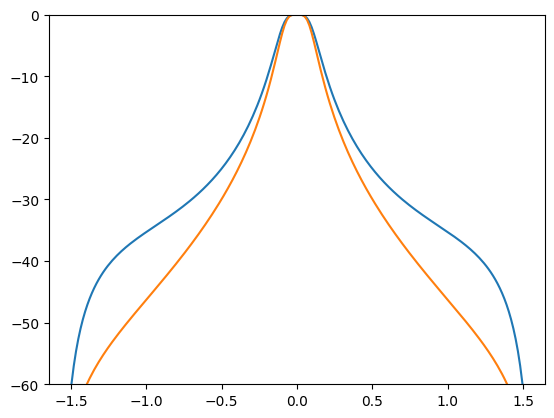

In [11]:
N = 3
f_0 = 5
alpha = 1.5
theta = np.linspace(-np.pi/2.1, np.pi/2.1, 200)
phi = np.array([0, np.pi/2])
e3 = np.abs(e_on_direction_array_only_with_similar_sheets(N, alpha, f_0, np.array([f_0]), phi, theta))[0][0]
e4 = np.abs(e_on_direction_array_only_with_similar_sheets(N, alpha, f_0, np.array([f_0]), phi, theta))[0][1]
print(np.max(e3))
print(np.max(e4))
plt.plot(theta, 20*np.log10(e3/np.max(e3)))
plt.plot(theta, 20*np.log10(e4/np.max(e4)))
plt.ylim(-60, 0)
plt.show()

In [12]:
def e_on_direction_only_with_similar_sheets(N, alpha, f_0, f, phi, theta):
    return e_on_direction_array_only_with_similar_sheets(N, alpha, f_0, np.array([f]), np.array([phi]), np.array([theta]))[0][0][0]

In [13]:
theta = np.linspace(0, 1, 11)
for theta_i in theta:
    print(theta_i, np.abs((e_on_direction_only_with_similar_sheets(1, 1.5, 5, 5, 0, theta_i)/2)**2))

0.0 4.0000632287879
0.1 3.927655712971675
0.2 3.6257024840402217
0.30000000000000004 2.9741346497656767
0.4 2.1025454315024295
0.5 1.3238215212776578
0.6000000000000001 0.7880187946327141
0.7000000000000001 0.46194192300308956
0.8 0.270419775162781
0.9 0.15728321710926552
1.0 0.08916477785096248


e_norm = 4.000031614269017
0.7198491749226351 5.899772266233783e-06
Directivity = 12.419683528137423 dBi
e_norm = 8.000113006096417
0.20499511205741633 2.4424648324564494e-07
Directivity = 17.874663582434152 dBi
e_norm = 16.00029067385329
0.05334611911245119 3.955831836903977e-09
Directivity = 23.721070336890367 dBi


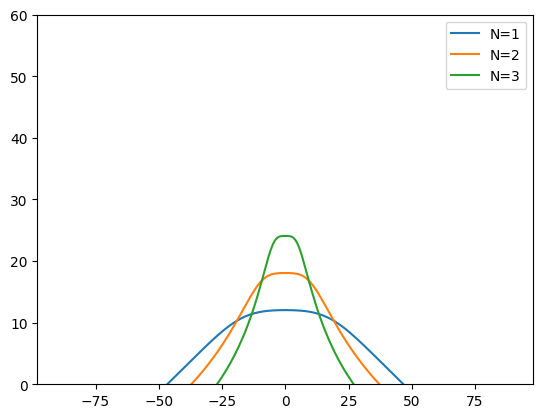

In [14]:
for N in [1, 2, 3]:
    f_0 = 5
    alpha = 1.5

    e_norm = np.abs(e_on_direction_only_with_similar_sheets(N, alpha, f_0, f_0, 0, 0))
    print('e_norm =', e_norm)
    #radiation_pattern_e_plane = lambda theta: np.abs(e_on_direction(N, eps, mu, l, theta = theta, phi=0)/max_e)**2
    radiation_pattern = lambda phi, theta: np.abs(e_on_direction_only_with_similar_sheets(N, alpha, f_0, f_0, phi, theta)/e_norm)**2 * np.sin(theta)
    res, err = integrate.dblquad(
        radiation_pattern,
        0, np.pi/2*0.99,                # границы для x
        lambda x: 0,          # нижняя граница y
        lambda x: np.pi*2*0.99,       # верхняя граница y
        epsrel=1e-2
    )
    #res_e, err_e = integrate.quad(radiation_pattern_e_plane, -np.pi/2, np.pi/2)
    #print('Directivity по E-плоскости =', 10*np.log10(2*np.pi/res_e), 'dBi')
    print(res, err)
    print('Directivity =', 10*np.log10(4*np.pi/res), 'dBi')
    theta = np.linspace(-np.pi/2*0.99, np.pi/2*0.99, 200)
    P = np.zeros(200)
    for i in range(len(theta)):
        P[i] = np.abs(e_on_direction_only_with_similar_sheets(N, alpha, f_0, f_0, 0, theta[i]))**2
    plt.plot(theta*180/np.pi, 10*np.log10(P), label=f'N={N}')
plt.ylim(0, 60)
plt.legend()
plt.show()

In [15]:
def directivity_only_with_similar_sheets(N, alpha, f_0, f):
    e_norm = np.abs(e_on_direction_only_with_similar_sheets(N, alpha, f_0, f, 0, 0))
    radiation_pattern = lambda phi, theta: np.abs(e_on_direction_only_with_similar_sheets(N, alpha, f_0, f, phi, theta)/e_norm)**2 * np.sin(theta)
    res, err = integrate.dblquad(
        radiation_pattern,
        0, np.pi/2*0.99,                # границы для x
        lambda x: 0,          # нижняя граница y
        lambda x: np.pi*2*0.99,       # верхняя граница y
        epsrel=1e-2
    )
    print(res, err)
    directivity = 4*np.pi/res
    return np.sqrt(directivity)

In [16]:
print(20*np.log10(directivity_only_with_similar_sheets(1, 1.5, 5, 5)), 'dBi')
print(directivity_only_with_similar_sheets(1, 1.5, 5, 5))

0.7198491749226351 5.899772266233783e-06
12.419683528137423 dBi
0.7198491749226351 5.899772266233783e-06
4.178151432036615


## для презы

In [39]:
cmap = plt.get_cmap('viridis')
cmap_new = plt.get_cmap('plasma')

1.0006293741586698 5.371111796091874e-07
0.9768933092337434 4.980878102979626e-07
0.9529710669460225 4.6671929962821716e-07
0.9288648400874479 4.453642641495299e-07
0.9045774952420078 4.3707150834330404e-07
0.880112720617854 4.4564709098213746e-07
0.855475207715357 4.7648437807838193e-07
0.830670875571438 5.374377827942477e-07
0.805707148889151 6.400357249384684e-07
0.7805933047818755 8.010549789838791e-07
0.7553409074481506 1.044464733328768e-06
0.7299643562878626 1.4019215919494248e-06
0.7044815813977773 1.9172485680933918e-06
0.6789149319315101 2.651685521894302e-06
0.6532923187420845 3.68443105741439e-06
0.6276486948565566 5.119586702113827e-06
0.6020279882547512 7.094532136294933e-06
0.5764856448362717 9.793608867009426e-06
0.5510920005795348 1.3472125489715538e-05
0.5259367879343106 1.8500449379837042e-05
0.5011352020033225 2.5431218528369707e-05
0.4768361187100977 3.516283536615639e-05
0.4532332815163135 4.925091860764455e-05
0.4305805598551212 7.045136781419312e-05
0.4092127103

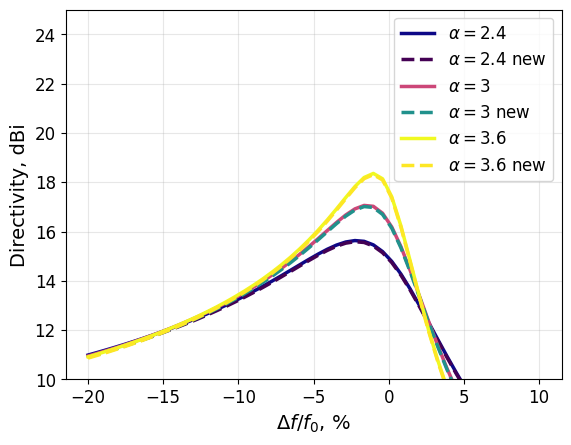

In [42]:
df = np.linspace(-20, 10, 50)
f_0 = 5
f = f_0 + df*f_0/100
dir_vs_freq = lambda a:np.array([directivity_only_with_similar_sheets(1, a, f_0, fi) for fi in f])
alpha = 2*np.array([1.2, 1.5, 1.8])
norm = plt.Normalize(min(alpha), max(alpha))
for alph in alpha:
    structure = LayeredStructure(alpha=np.array([alph]), beta='first_approx')
    df_new = df/100
    plt.plot(df, 20*np.log10(dir_vs_freq(alph)), label=(r'$\alpha=$' + f"{alph:.2g}"), color=cmap_new(norm(alph)), linewidth=2.5)
    plt.plot(df, 10*np.log10(structure.directivity(df_new)), label=(r'$\alpha=$' + f"{alph:.2g} new"), color=cmap(norm(alph)), linewidth=2.5, linestyle='dashed')
plt.legend(fontsize=12)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.xlabel(r'$\Delta f / f_0$, %', fontsize=14)
plt.ylabel('Directivity, dBi', fontsize=14)
plt.grid(alpha=0.3)
plt.ylim(10, 25)
plt.show()

e_norm = 8.472214710340472
0.17904271382206494 8.357612149219859e-11
Directivity = 18.462532120126685 dBi


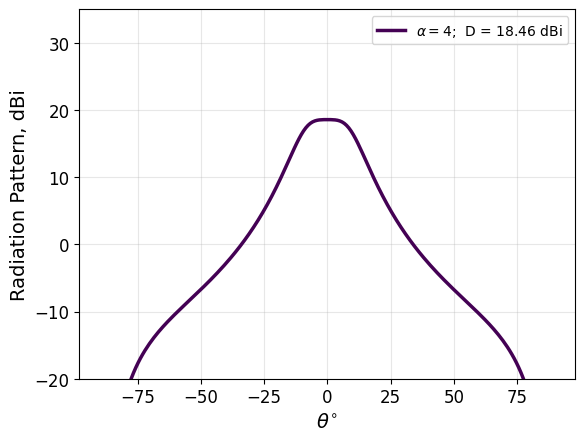

In [19]:
alpha_arr = [4]
norm = plt.Normalize(min(alpha_arr), max(alpha_arr))
for alpha in alpha_arr:
    f_0 = 5
    df = 0
    N = 1

    e_norm = np.abs(e_on_direction_only_with_similar_sheets(N, alpha, f_0, f_0*(1+df), 0, 0))
    print('e_norm =', e_norm)
    #radiation_pattern_e_plane = lambda theta: np.abs(e_on_direction(N, eps, mu, l, theta = theta, phi=0)/max_e)**2
    radiation_pattern = lambda phi, theta: np.abs(e_on_direction_only_with_similar_sheets(N, alpha, f_0, f_0*(1+df), phi, theta)/e_norm)**2 * np.sin(theta)
    res, err = integrate.dblquad(
        radiation_pattern,
        0, np.pi/2*0.999,                # границы для x
        lambda x: 0,          # нижняя граница y
        lambda x: np.pi*2,       # верхняя граница y
        epsrel=1e-8
    )
    #res_e, err_e = integrate.quad(radiation_pattern_e_plane, -np.pi/2, np.pi/2)
    #print('Directivity по E-плоскости =', 10*np.log10(2*np.pi/res_e), 'dBi')
    print(res, err)
    print('Directivity =', 10*np.log10(4*np.pi/res), 'dBi')
    theta = np.linspace(-np.pi/2*0.99, np.pi/2*0.99, 200)
    P = np.zeros(200)
    for i in range(len(theta)):
        P[i] = np.abs(e_on_direction_only_with_similar_sheets(N, alpha, f_0, f_0*(1+df), 0, theta[i]))**2
    plt.plot(theta*180/np.pi, 10*np.log10(P), label=(r'$\alpha={}$'.format(alpha) + '; ' ' D = ' + f"{10*np.log10(4*np.pi/res):.2f} dBi"), color=cmap(norm(alpha)), linewidth=2.5)
plt.ylim(-20, 35)
plt.legend(fontsize=12)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.xlabel(r'$\theta^{\circ}$', fontsize=14)
plt.ylabel('Radiation Pattern, dBi', fontsize=14)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

e_norm = 3.236090947905541
1.0440738561434018 1.2014740888204605e-10
Directivity = 10.804786429602316 dBi
e_norm = 4.000031614269017
0.7272091767533643 5.0359814651839536e-11
Directivity = 12.375505133513624 dBi
e_norm = 4.82846798166964
0.5214736411231654 1.447894336300019e-10
Directivity = 13.819775029452066 dBi


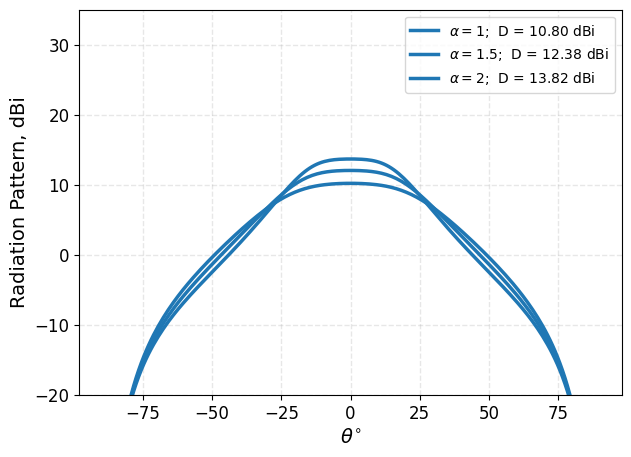

In [ ]:
alpha_arr = [1, 1.5, 2]
norm = plt.Normalize(min(alpha_arr), max(alpha_arr))
fig, ax = plt.subplots(figsize=(7, 5))
for alpha in alpha_arr:
    f_0 = 5
    df = 0
    N = 1

    e_norm = np.abs(e_on_direction_only_with_similar_sheets(N, alpha, f_0, f_0*(1+df), 0, 0))
    print('e_norm =', e_norm)
    #radiation_pattern_e_plane = lambda theta: np.abs(e_on_direction(N, eps, mu, l, theta = theta, phi=0)/max_e)**2
    radiation_pattern = lambda phi, theta: np.abs(e_on_direction_only_with_similar_sheets(N, alpha, f_0, f_0*(1+df), phi, theta)/e_norm)**2 * np.sin(theta)
    res, err = integrate.dblquad(
        radiation_pattern,
        0, np.pi/2*0.999,                # границы для x
        lambda x: 0,          # нижняя граница y
        lambda x: np.pi*2,       # верхняя граница y
        epsrel=1e-8
    )
    #res_e, err_e = integrate.quad(radiation_pattern_e_plane, -np.pi/2, np.pi/2)
    #print('Directivity по E-плоскости =', 10*np.log10(2*np.pi/res_e), 'dBi')
    print(res, err)
    print('Directivity =', 10*np.log10(4*np.pi/res), 'dBi')
    theta = np.linspace(-np.pi/2*0.99, np.pi/2*0.99, 200)
    P = np.zeros(200)
    for i in range(len(theta)):
        P[i] = np.abs(e_on_direction_only_with_similar_sheets(N, alpha, f_0, f_0*(1+df), np.pi/2, theta[i]))**2
    ax.plot(theta*180/np.pi, 10*np.log10(P), label=(r'$\alpha={:.2f}$'.format(alpha) + '; ' ' D = ' + f"{10*np.log10(4*np.pi/res):.2f} dBi"), color = 'C0', linewidth=2.5)
ax.set_ylim(-20, 35)
ax.legend(fontsize=14, )
ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=12)
ax.set_xlabel(r'$\theta^{\circ}$', fontsize=14)
ax.set_ylabel('Radiation Pattern, dBi', fontsize=14)
ax.legend()
ax.grid(alpha=0.3, linestyle='--', linewidth=1)
plt.show()

In [21]:
from My_plotter import Style, Plotter
from T_method import LayeredStructure

In [23]:
structure = LayeredStructure(alpha=np.array([1.5, 1.5, 1.5]), beta='first_approx')
print(structure.beta)
newstyle = Style(line_style='--', cmap='plasma')

[2.67794504 0.64350111 0.64350111]


e_norm = 2.561568220503141
1.5536430529577379 2.9640341874215097e-10
Directivity = 9.078586165695803 dBi
e_norm = 7.843393955870924
0.2083518458056967 3.6217363783161745e-11
Directivity = 17.804125117621428 dBi
e_norm = 13.953455147369764
0.06611730375239112 1.1979027845606325e-11
Directivity = 22.788947291852075 dBi
e_norm = 20.19812301795811
0.03138285984485199 8.749695497942692e-11
Directivity = 26.02517346751877 dBi


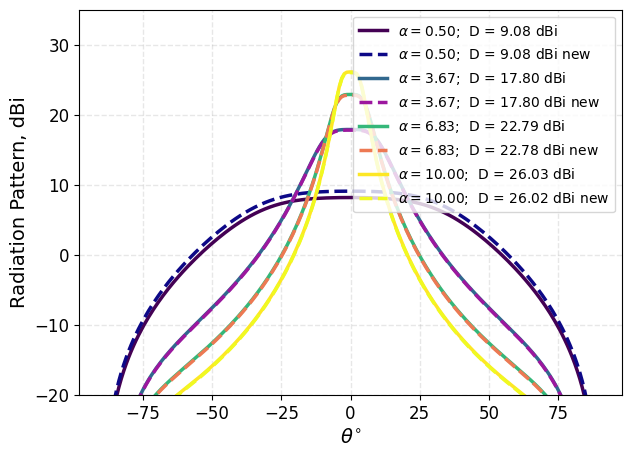

In [35]:
style = Style()
alpha_arr = np.linspace(0.5, 10, 4)
fig, ax = plt.subplots(figsize=(7, 5))
pl = Plotter(ax, style)
pl_new = Plotter(ax, newstyle)
pl.set_xlabel(r'$\theta^{\circ}$')
pl.set_ylabel('Radiation Pattern, dBi')
pl.set_ylim((-20, 35))
pl.set_p(alpha_arr)
pl_new.set_p(alpha_arr)
for alpha in alpha_arr:
    f_0 = 5
    df = 0
    N = 1

    e_norm = np.abs(e_on_direction_only_with_similar_sheets(N, alpha, f_0, f_0*(1+df), 0, 0))
    print('e_norm =', e_norm)
    #radiation_pattern_e_plane = lambda theta: np.abs(e_on_direction(N, eps, mu, l, theta = theta, phi=0)/max_e)**2
    radiation_pattern = lambda phi, theta: np.abs(e_on_direction_only_with_similar_sheets(N, alpha, f_0, f_0*(1+df), phi, theta)/e_norm)**2 * np.sin(theta)
    res, err = integrate.dblquad(
        radiation_pattern,
        0, np.pi/2*0.99,                # границы для x
        lambda x: 0,          # нижняя граница y
        lambda x: np.pi*2,       # верхняя граница y
        epsrel=1e-8
    )
    #res_e, err_e = integrate.quad(radiation_pattern_e_plane, -np.pi/2, np.pi/2)
    #print('Directivity по E-плоскости =', 10*np.log10(2*np.pi/res_e), 'dBi')
    print(res, err)
    print('Directivity =', 10*np.log10(4*np.pi/res), 'dBi')
    theta = np.linspace(-np.pi/2*0.99, np.pi/2*0.99, 200)
    P = np.zeros(200)
    for i in range(len(theta)):
        P[i] = np.abs(e_on_direction_only_with_similar_sheets(N, alpha, f_0, f_0*(1+df), np.pi/4, theta[i]))**2
    label = (r'$\alpha={:.2f}$'.format(alpha) + '; ' ' D = ' + f"{10*np.log10(4*np.pi/res):.2f} dBi")
    structure = LayeredStructure(alpha=np.array([alpha]), beta='first_approx')
    df = np.array([0])
    phi = np.array([np.pi/4])
    pdB = 10*np.log10(structure.radiation_pattern(phi, theta, df, mode='absolute')[0, 0, :])
    dir = 10*np.log10(structure.directivity(df))
    label_new = (r'$\alpha={:.2f}$'.format(alpha) + '; ' ' D = ' + f"{dir[0]:.2f} dBi new")
    pl.multiple_plot(theta*180/np.pi, 10*np.log10(P), alpha, label=label)
    pl_new.multiple_plot(theta*180/np.pi, pdB, alpha, label=label_new)
pl.finalize()

In [104]:
print(f())
print(f())

1
1


In [ ]:
a = np.array([1, 2, 3])
b = a*2

b[0] = 99

print(a)  # [1  2  3]

[1 2 3]
